<a href="https://colab.research.google.com/github/rohan604037/ML-lab/blob/main/lab6/6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

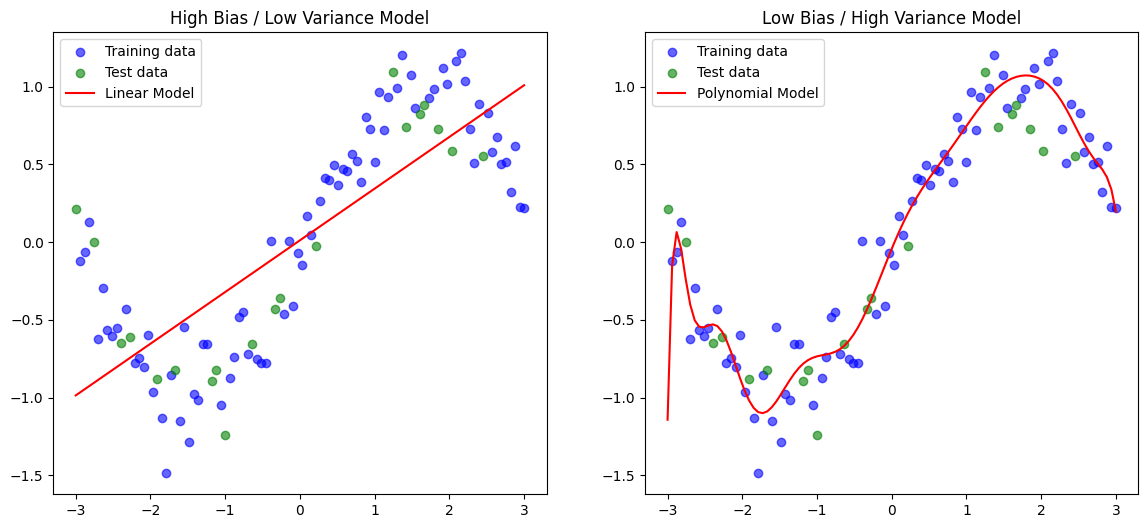

Linear Model Training MSE: 0.19743335485331392
Linear Model Testing MSE: 0.24695224333039673
Polynomial Model Training MSE: 0.029514806989774718
Polynomial Model Testing MSE: 0.1425297085836628


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
# Generate a synthetic dataset
np.random.seed(0)
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.random.normal(0, 0.2, 100) # Adding noise
X = X[:, np.newaxis] # Reshape for sklearn
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# High Bias / Low Variance Model (Linear Regression)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_train_linear = linear_model.predict(X_train)
y_pred_test_linear = linear_model.predict(X_test)
# Low Bias / High Variance Model (Polynomial Regression with high degree)
poly_model = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())
poly_model.fit(X_train, y_train)
y_pred_train_poly = poly_model.predict(X_train)
y_pred_test_poly = poly_model.predict(X_test)
# Plotting
plt.figure(figsize=(14, 6))
# Linear Model Plot
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, label='Training data', color='blue', alpha=0.6)
plt.scatter(X_test, y_test, label='Test data', color='green', alpha=0.6)
plt.plot(X, linear_model.predict(X), color='red', label='Linear Model')
plt.title('High Bias / Low Variance Model')
plt.legend()
# Polynomial Model Plot
plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, label='Training data', color='blue', alpha=0.6)
plt.scatter(X_test, y_test, label='Test data', color='green', alpha=0.6)
plt.plot(np.linspace(-3, 3, 100), poly_model.predict(np.linspace(-3, 3, 100)[:,
np.newaxis]), color='red', label='Polynomial Model')
plt.title('Low Bias / High Variance Model')
plt.legend()
plt.show()
# Print Mean Squared Error for both models
print(f"Linear Model Training MSE: {mean_squared_error(y_train,
y_pred_train_linear)}")
print(f"Linear Model Testing MSE: {mean_squared_error(y_test, y_pred_test_linear)}")
print(f"Polynomial Model Training MSE: {mean_squared_error(y_train,
y_pred_train_poly)}")
print(f"Polynomial Model Testing MSE: {mean_squared_error(y_test,
y_pred_test_poly)}")

In [8]:
# Calculate Mean Squared Error (MSE) for training and testing sets
mse_train_linear = mean_squared_error(y_train, y_pred_train_linear)
mse_test_linear = mean_squared_error(y_test, y_pred_test_linear)
mse_train_poly = mean_squared_error(y_train, y_pred_train_poly)
mse_test_poly = mean_squared_error(y_test, y_pred_test_poly)
# Display MSE for both models
print("Linear Regression Model (High Bias/Low Variance)")
print(f"Training MSE: {mse_train_linear}")
print(f"Testing MSE: {mse_test_linear}\n")
print("Polynomial Regression Model (Low Bias/High Variance)")
print(f"Training MSE: {mse_train_poly}")
print(f"Testing MSE: {mse_test_poly}")

Linear Regression Model (High Bias/Low Variance)
Training MSE: 0.19743335485331392
Testing MSE: 0.24695224333039673

Polynomial Regression Model (Low Bias/High Variance)
Training MSE: 0.029514806989774718
Testing MSE: 0.1425297085836628


In [9]:
from mlxtend.evaluate import bias_variance_decomp
mse, bias, var = bias_variance_decomp(linear_model, X_train, y_train, X_test, y_test,
loss='mse', num_rounds=200, random_seed=1)
# summarize results
print('MSE: %.3f' % mse)
print('Bias: %.3f' % bias)
print('Variance: %.3f' % var)

MSE: 0.253
Bias: 0.247
Variance: 0.006


In [10]:
mse, bias, var = bias_variance_decomp(poly_model, X_train, y_train, X_test, y_test,
loss='mse', num_rounds=200, random_seed=1)
# summarize results
print('MSE: %.3f' % mse)
print('Bias: %.3f' % bias)
print('Variance: %.3f' % var)

MSE: 2.609
Bias: 0.140
Variance: 2.468
